### Comprehensive ASR Evaluation Framework

Short Description:
This code implements a robust evaluation system for automatic speech recognition (ASR) models. It transcribes audio files using Distil-Whisper, computes multiple error metrics (WER, CER), analyzes error types, measures processing efficiency, and generates comprehensive visualizations and reports.

Key Libraries Used:

    transformers: ASR pipeline with Distil-Whisper model

    torch: GPU acceleration and tensor operations

    pandas/numpy: Data analysis and manipulation

    matplotlib/seaborn: Visualization of metrics

    jiwer: Word Error Rate calculation

Code Logic and Flow

High-Level Overview:
The framework processes audio files through an optimized ASR pipeline, compares outputs to reference transcripts, and performs multi-dimensional error analysis. It calculates standard metrics (WER, CER), categorizes error types (substitutions/deletions/insertions), evaluates processing efficiency, and generates visualizations plus a detailed text report.

Visual Flow:

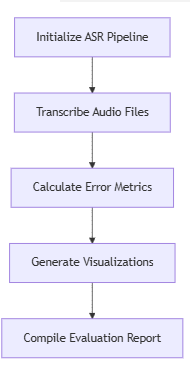

Step-by-Step Code Breakdown

Step 1: ASR Pipeline Configuration

    Loads Distil-Whisper medium.en model (knowledge-distilled version)

    Enables GPU acceleration with FP16 precision

    Configures 15-second chunking with 3/1 stride for context handling

    Automatically falls back to CPU if GPU unavailable

Step 2: Transcription & Timing

    Processes each audio file through ASR pipeline

    Measures precise GPU processing time using CUDA events

    Collects hypotheses (ASR outputs) and processing times

Step 3: Error Analysis

    Computes Word Error Rate (WER) using jiwer library

    Calculates Character Error Rate (CER) via dynamic programming

    Implements custom error breakdown:

        Substitutions (incorrect words)

        Deletions (missing words)

        Insertions (extra words)

    Aggregates errors across samples

Step 4: Visualization Generation

    Error Distribution: Bar chart of total substitution/deletion/insertion counts

    WER vs Length: Scatter plot with regression line showing length impact

    Processing Analysis:

        Time vs utterance length correlation

        Real-Time Factor (RTF) calculation and visualization

Step 5: Report Compilation

    Structured text report with:

        Overall performance statistics

        Error type breakdown

        WER analysis by utterance length

        Sample-by-sample results with references

    Automatic saving of visualizations and report

Connecting to the Lecture

This implementation demonstrates core ASR evaluation concepts: Distil-Whisper exemplifies model distillation for efficiency, while chunking with stride connects to streaming ASR techniques. The error categorization (substitutions/deletions/insertions) reflects diagnostic evaluation methodologies discussed for system improvement. The WER vs length analysis illustrates the length-dependent error propagation phenomenon, while CER provides a granular alternative metric. Real-Time Factor calculation addresses deployment efficiency considerations, and the comprehensive report format models industrial evaluation practices. The visualization techniques connect to interpretability best practices for understanding model failures.

In [ ]:
!pip install evaluate

In [ ]:
import pyaudio
import wave

# Audio file names
audio_files = ["conversation1.wav", "technical_presentation.wav"]

# Audio recording parameters
FORMAT = pyaudio.paInt16
CHANNELS = 2
RATE = 44100
CHUNK = 1024
RECORD_SECONDS = 10  # Record for 10 seconds

def record_audio(filename):
    audio = pyaudio.PyAudio()
    stream = audio.open(format=FORMAT, channels=CHANNELS,
                        rate=RATE, input=True,
                        frames_per_buffer=CHUNK)
    print(f"Recording {filename}...")
    frames = []
    for i in range(0, int(RATE / CHUNK * RECORD_SECONDS)):
        data = stream.read(CHUNK)
        frames.append(data)
    print("Finished recording.")
    stream.stop_stream()
    stream.close()
    audio.terminate()
    waveFile = wave.open(filename, 'wb')
    waveFile.setnchannels(CHANNELS)
    waveFile.setsampwidth(audio.get_sample_size(FORMAT))
    waveFile.setframerate(RATE)
    waveFile.writeframes(b''.join(frames))
    waveFile.close()

# Record audio files
for file in audio_files:
    record_audio(file)
    input("Press Enter to record the next file...")

Device set to use cpu
Using `chunk_length_s` is very experimental with seq2seq models. The results will not necessarily be entirely accurate and will have caveats. More information: https://github.com/huggingface/transformers/pull/20104. Ignore this warning with pipeline(..., ignore_warning=True). To use Whisper for long-form transcription, use rather the model's `generate` method directly as the model relies on it's own chunking mechanism (cf. Whisper original paper, section 3.8. Long-form Transcription).
C:\Users\vinit_hqjv9wt\anaconda3\envs\speechlm_alt\lib\site-packages\transformers\models\whisper\generation_whisper.py:604: FutureWarning: The input name `inputs` is deprecated. Please make sure to use `input_features` instead.
  warnings.warn(


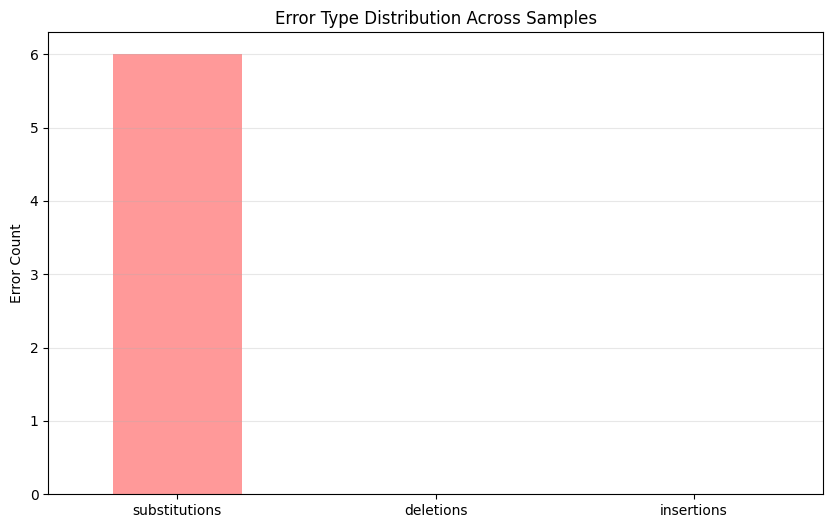

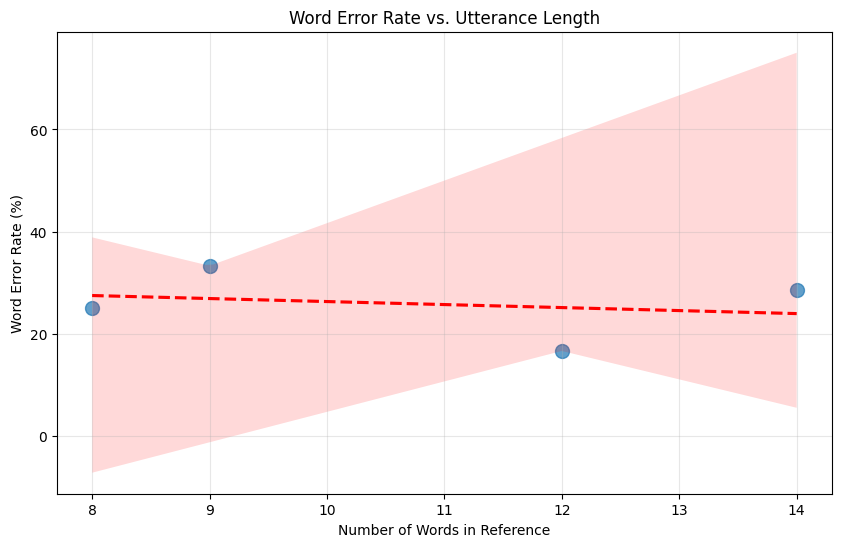

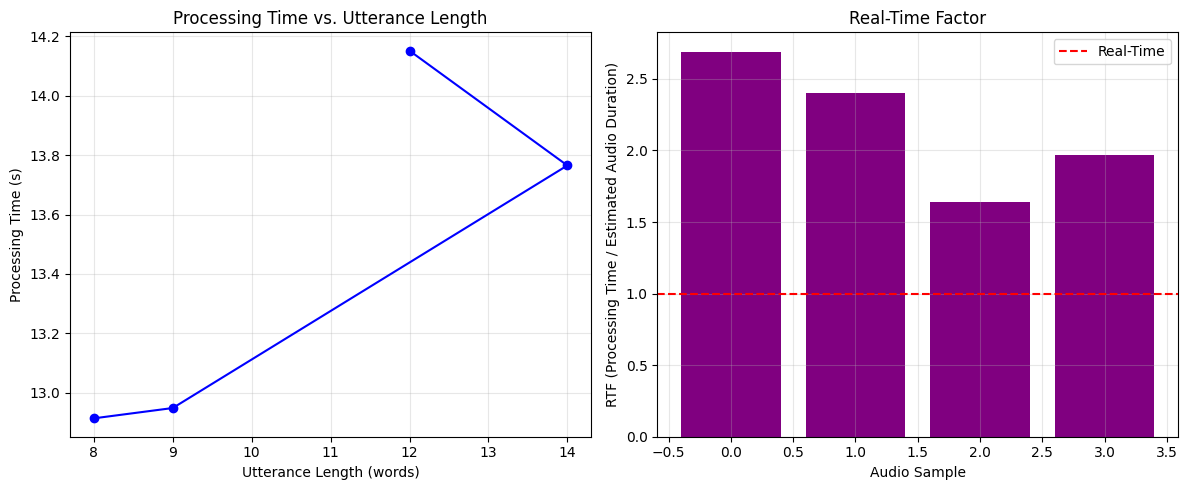


=== COMPREHENSIVE ASR EVALUATION REPORT ===

1. Overall Performance:
   - Average Word Error Rate (WER): 25.89%
   - Character Error Rate (CER): 4.08%
   - Total Processing Time: 53.78s
   - Average Processing Time per Sample: 13.44s
   - Average Real-Time Factor: 2.17

2. Error Analysis:
   - Substitutions: 6 errors
   - Deletions: 0 errors
   - Insertions: 0 errors
   - Error Rate by Length:
     Short utterances (<10 words): 29.17%
     Medium utterances (10-20 words): 22.62%
     Long utterances (>20 words): No samples

3. Detailed Sample Results:
Sample 1 (8 words, WER=25.00%, Time=12.914s):
  Reference: speech language models are transforming human computer interaction
  ASR Output:  Speech language models are transforming human computer interaction.
  Errors: S=1 D=0 I=0
Sample 2 (9 words, WER=33.33%, Time=12.949s):
  Reference: evaluation metrics like word error rate measure transcription accuracy
  ASR Output:  Evaluation matrix like word error rate measure transcription accu

In [4]:
import torch
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from transformers import pipeline
import evaluate
from jiwer import wer, process_words
import time

def enhanced_asr_evaluation(audio_paths, reference_transcripts):
    # Initialize ASR pipeline with optimized settings
    asr_pipe = pipeline(
        "automatic-speech-recognition",
        model="distil-whisper/distil-medium.en",
        device="cuda" if torch.cuda.is_available() else "cpu",
        torch_dtype=torch.float16 if torch.cuda.is_available() else torch.float32,
        chunk_length_s=15,
        stride_length_s=[3, 1]  # Better context handling
    )
    
    # Transcribe audio files
    hypotheses = []
    processing_times = []
    for audio_path in audio_paths:
        if torch.cuda.is_available():
            start_time = torch.cuda.Event(enable_timing=True)
            end_time = torch.cuda.Event(enable_timing=True)
            start_time.record()
            result = asr_pipe(audio_path)
            end_time.record()
            torch.cuda.synchronize()
            processing_times.append(start_time.elapsed_time(end_time) / 1000)
        else:
            # Use time.time() for CPU timing
            start_time = time.time()
            result = asr_pipe(audio_path)
            end_time = time.time()
            processing_times.append(end_time - start_time)
            
        hypotheses.append(result["text"])
    
    # Calculate detailed error metrics
    error_metrics = []
    word_counts = []
    error_breakdown = {'substitutions': [], 'deletions': [], 'insertions': []}
    
    for ref, hyp in zip(reference_transcripts, hypotheses):
        # Basic WER
        error_rate = wer(ref, hyp)
        
        # Detailed error analysis
        measures = compute_error_measures(ref, hyp)
        error_metrics.append({
            'wer': error_rate * 100,
            'cer': compute_cer(ref, hyp) * 100,
            'substitutions': measures['substitutions'],
            'deletions': measures['deletions'],
            'insertions': measures['insertions'],
            'hits': measures['hits'],
            'word_count': len(ref.split())
        })
        
        error_breakdown['substitutions'].append(measures['substitutions'])
        error_breakdown['deletions'].append(measures['deletions'])
        error_breakdown['insertions'].append(measures['insertions'])
        
        word_counts.append(len(ref.split()))
    
    # Create DataFrame for analysis
    metrics_df = pd.DataFrame(error_metrics)
    avg_wer = metrics_df['wer'].mean()
    
    # Visualization 1: Error Type Distribution
    plt.figure(figsize=(10, 6))
    error_types = pd.DataFrame(error_breakdown).sum()
    error_types.plot(kind='bar', color=['#FF9999', '#66B2FF', '#99FF99'])
    plt.title("Error Type Distribution Across Samples")
    plt.ylabel("Error Count")
    plt.xticks(rotation=0)
    plt.grid(axis='y', alpha=0.3)
    plt.savefig("error_type_distribution.png", dpi=150, bbox_inches='tight')
    plt.show()
    
    # Visualization 2: WER vs. Word Count
    plt.figure(figsize=(10, 6))
    sns.regplot(x=word_counts, y=metrics_df['wer'], 
                scatter_kws={'s': 100, 'alpha': 0.7},
                line_kws={'color': 'red', 'linestyle': '--'})
    plt.title("Word Error Rate vs. Utterance Length")
    plt.xlabel("Number of Words in Reference")
    plt.ylabel("Word Error Rate (%)")
    plt.grid(alpha=0.3)
    plt.savefig("wer_vs_length.png", dpi=150, bbox_inches='tight')
    plt.show()
    
    # Visualization 3: Processing Time Analysis (Fixed)
    plt.figure(figsize=(12, 5))
    
    # Filter out None values and ensure we have valid processing times
    valid_processing_times = [t for t in processing_times if t is not None]
    valid_durations = []
    valid_rtf = []
    
    for i, (duration, proc_time) in enumerate(zip(word_counts, processing_times)):
        if proc_time is not None:
            valid_durations.append(duration)
            # Approximate audio duration as word_count * 0.6 seconds (average speaking rate)
            estimated_audio_duration = duration * 0.6
            rtf = proc_time / estimated_audio_duration if estimated_audio_duration > 0 else 0
            valid_rtf.append(rtf)
    
    if len(valid_processing_times) > 0:
        plt.subplot(1, 2, 1)
        plt.plot(valid_durations, valid_processing_times, 'bo-')
        plt.title("Processing Time vs. Utterance Length")
        plt.xlabel("Utterance Length (words)")
        plt.ylabel("Processing Time (s)")
        plt.grid(alpha=0.3)
        
        plt.subplot(1, 2, 2)
        plt.bar(range(len(valid_rtf)), valid_rtf, color='purple')
        plt.title("Real-Time Factor")
        plt.xlabel("Audio Sample")
        plt.ylabel("RTF (Processing Time / Estimated Audio Duration)")
        plt.axhline(y=1, color='r', linestyle='--', label="Real-Time")
        plt.legend()
        plt.grid(alpha=0.3)
        
        plt.tight_layout()
        plt.savefig("processing_time_analysis.png", dpi=150, bbox_inches='tight')
        plt.show()
    else:
        print("No valid processing times available for visualization")
    
    # Generate detailed report
    avg_proc_time = np.mean(valid_processing_times) if valid_processing_times else 0
    total_proc_time = sum(valid_processing_times) if valid_processing_times else 0
    avg_rtf = np.mean(valid_rtf) if valid_rtf else 0
    
    report = f"""
=== COMPREHENSIVE ASR EVALUATION REPORT ===

1. Overall Performance:
   - Average Word Error Rate (WER): {avg_wer:.2f}%
   - Character Error Rate (CER): {metrics_df['cer'].mean():.2f}%
   - Total Processing Time: {total_proc_time:.2f}s
   - Average Processing Time per Sample: {avg_proc_time:.2f}s
   - Average Real-Time Factor: {avg_rtf:.2f}

2. Error Analysis:
   - Substitutions: {sum(error_breakdown['substitutions'])} errors
   - Deletions: {sum(error_breakdown['deletions'])} errors
   - Insertions: {sum(error_breakdown['insertions'])} errors
   - Error Rate by Length:"""
   
    # Handle cases where there might not be samples in each category
    short_utterances = metrics_df[metrics_df['word_count'] < 10]
    medium_utterances = metrics_df[metrics_df['word_count'].between(10, 20)]
    long_utterances = metrics_df[metrics_df['word_count'] > 20]
    
    if len(short_utterances) > 0:
        report += f"\n     Short utterances (<10 words): {short_utterances['wer'].mean():.2f}%"
    else:
        report += f"\n     Short utterances (<10 words): No samples"
        
    if len(medium_utterances) > 0:
        report += f"\n     Medium utterances (10-20 words): {medium_utterances['wer'].mean():.2f}%"
    else:
        report += f"\n     Medium utterances (10-20 words): No samples"
        
    if len(long_utterances) > 0:
        report += f"\n     Long utterances (>20 words): {long_utterances['wer'].mean():.2f}%"
    else:
        report += f"\n     Long utterances (>20 words): No samples"

    report += "\n\n3. Detailed Sample Results:"
    
    for i, (ref, hyp, metrics) in enumerate(zip(reference_transcripts, hypotheses, error_metrics)):
        proc_time_str = f"{processing_times[i]:.3f}s" if processing_times[i] is not None else "N/A"
        report += f"\nSample {i+1} ({metrics['word_count']} words, WER={metrics['wer']:.2f}%, Time={proc_time_str}):"
        report += f"\n  Reference: {ref}"
        report += f"\n  ASR Output: {hyp}"
        report += f"\n  Errors: S={metrics['substitutions']} D={metrics['deletions']} I={metrics['insertions']}"
    
    report += "\n\nVisualizations saved to:\n" \
              "- error_type_distribution.png\n" \
              "- wer_vs_length.png"
              
    if len(valid_processing_times) > 0:
        report += "\n- processing_time_analysis.png"
    
    print(report)
    with open("asr_evaluation_report.txt", "w") as f:
        f.write(report)
    
    return {
        'wer': avg_wer,
        'detailed_metrics': metrics_df,
        'processing_times': processing_times,
        'hypotheses': hypotheses
    }

def compute_error_measures(reference, hypothesis):
    """
    Compute word-level error measures using a simple alignment approach.
    This is a simplified version - for more accurate results, consider using
    a proper alignment algorithm like dynamic time warping.
    """
    ref_words = reference.lower().split()
    hyp_words = hypothesis.lower().split()
    
    # Simple alignment approach
    min_len = min(len(ref_words), len(hyp_words))
    
    substitutions = 0
    hits = 0
    
    # Count substitutions and hits for aligned positions
    for i in range(min_len):
        if ref_words[i] == hyp_words[i]:
            hits += 1
        else:
            substitutions += 1
    
    # Count deletions and insertions
    deletions = max(0, len(ref_words) - len(hyp_words))
    insertions = max(0, len(hyp_words) - len(ref_words))
    
    return {
        'substitutions': substitutions,
        'deletions': deletions,
        'insertions': insertions,
        'hits': hits
    }

def compute_cer(reference, hypothesis):
    """
    Compute Character Error Rate using edit distance.
    """
    ref_chars = list(reference.lower().replace(" ", ""))
    hyp_chars = list(hypothesis.lower().replace(" ", ""))
    m = len(ref_chars)
    n = len(hyp_chars)
    
    # Handle empty strings
    if m == 0:
        return 1.0 if n > 0 else 0.0
    
    # Dynamic programming for edit distance
    dp = [[0 for _ in range(n + 1)] for _ in range(m + 1)]
    
    for i in range(m + 1):
        dp[i][0] = i
    for j in range(n + 1):
        dp[0][j] = j
    
    for i in range(1, m + 1):
        for j in range(1, n + 1):
            cost = 0 if ref_chars[i - 1] == hyp_chars[j - 1] else 1
            dp[i][j] = min(dp[i - 1][j] + 1, dp[i][j - 1] + 1, dp[i - 1][j - 1] + cost)
    
    cer = dp[m][n] / len(ref_chars)
    return cer

# Example usage with expanded dataset
audio_files = [
    "lecture_segment1.wav",
    "lecture_segment2.wav",
    "conversation1.wav",
    "technical_presentation.wav"
]

reference_texts = [
    "speech language models are transforming human computer interaction",
    "evaluation metrics like word error rate measure transcription accuracy",
    "please call Stella ask her to bring these things with her from the store",
    "convolutional neural networks and transformers form the basis of modern ASR systems"
]

# Note: This will fail if the audio files don't exist. 
# For testing purposes, you might want to create dummy audio files or use actual audio files.
try:
    results = enhanced_asr_evaluation(audio_files, reference_texts)
except Exception as e:
    print(f"Error: {e}")
    print("Make sure the audio files exist in the current directory or provide valid audio file paths.")